## 1. Motivation and Research Question

My motivation for this project comes from my own experience as an international student studying Data Science in the United States. I often use large language models in both Chinese and English, and I noticed that asking the same question in different languages can sometimes lead to different answers. Even when the Chinese and English prompts have almost the same meaning, the model's responses are not always equivalent after translation.

At first, I thought the model might simply translate Chinese input into English, process the meaning in an English-centered space, and then translate the answer back into Chinese. However, the difference in outputs made me think that the process may be more complex. The input language itself, the wording, and the cultural background of a concept may all affect how the model represents and responds to the input.

Instead of directly comparing final generated answers, which can be affected by many factors, this project focuses on the model's internal representations. I study whether semantically equivalent Chinese and English sentences become more similar across the hidden layers of a multilingual model. I also compare neutral daily sentences with culturally loaded sentences, because some concepts may carry different associations in Chinese and English even when their literal meanings are similar.

The main research question is:

**If a Chinese sentence and an English sentence convey the same meaning, does a multilingual model represent them as increasingly similar across its internal hidden layers?**

This leads to another question:

**Is this cross-lingual alignment weaker or delayed for culturally loaded concepts compared with neutral sentences?**

## 2. Dataset Construction

To answer the two research questions, I use a synthetic Chinese-English sentence-pair dataset. Each row contains one English sentence and one Chinese sentence that are intended to express the same basic meaning.

The dataset is balanced between two categories: neutral sentence pairs and culturally loaded sentence pairs. Neutral examples describe simple daily meanings, such as actions, objects, school activities, weather, and locations. Culturally loaded examples contain concepts that may carry different associations in Chinese and English, such as cultural symbols, family values, social norms, festivals, colors, idioms, or traditions.

This dataset is used in two ways. For RQ1, I ignore the category labels and treat all examples as semantically equivalent Chinese-English pairs. This allows me to test whether cross-lingual alignment generally increases across hidden layers. For RQ2, I use the category labels to compare whether culturally loaded sentence pairs show weaker, slower, or less stable alignment than neutral sentence pairs.

The dataset is synthetically generated and then manually inspected. It is not intended to be a large real-world benchmark. Instead, it is a controlled exploratory dataset designed for representation-level analysis.

Before generating the dataset, I defined the two main categories and several subcategories. This helps make the dataset more controlled and balanced.

For neutral examples, I include ordinary sentences about daily actions, objects, school or work, weather, emotions, and locations. These examples are expected to have relatively direct semantic equivalents across Chinese and English.

For culturally loaded examples, I include sentences about cultural symbols, family values, social norms, festivals, colors, idioms, and traditions. These examples are still designed to be semantically equivalent across languages, but they may contain concepts with different cultural associations.

Prompt:

Generate a synthetic dataset for a cross-lingual semantic alignment project.

I need 100 Chinese-English sentence pairs.

Requirements:
1. Each pair should contain one English sentence and one Chinese sentence.
2. The English and Chinese sentences should express the same basic meaning.
3. Create 50 neutral sentence pairs and 50 culturally loaded sentence pairs.
4. Neutral sentences should describe simple everyday actions, objects, emotions, school/work activities, weather, or locations.
5. Culturally loaded sentences should involve cultural symbols, family values, social norms, festivals, traditions, colors, idioms, or concepts that may carry different associations in Chinese and English.
6. Keep each sentence short and clear.
7. Avoid names of real people, politics, religion, sensitive topics, or offensive stereotypes.
8. Do not make the Chinese sentence a word-for-word awkward translation. It should sound natural.
9. Return the result as a CSV table with columns:
id, category, subcategory, english, chinese, notes

Make sure the dataset is balanced:
- 50 neutral
- 50 cultural

In [27]:
#import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("project.csv")
df.head()

,id,category,subcategory,english,chinese,notes,translated_english
0,1,neutral,everyday_action,I opened the window in the morning.,我早上打开了窗户。,simple daily action,"This morning, I opened the window."
1,2,neutral,everyday_action,She washed her cup after breakfast.,她吃完早饭后洗了杯子。,simple daily action,"After finishing breakfast, she cleaned her cup."
2,3,neutral,everyday_action,He put his keys on the table.,他把钥匙放在桌上。,simple daily action,He set the keys down on the table.
3,4,neutral,everyday_action,I walked to the store nearby.,我走路去了附近的商店。,simple daily action,I went on foot to a nearby shop.
4,5,neutral,everyday_action,They cleaned the room together.,他们一起打扫了房间。,simple daily action,They tidied the room together.


In [28]:
#check data informations
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  100 non-null    int64 
 1   category            100 non-null    object
 2   subcategory         100 non-null    object
 3   english             100 non-null    object
 4   chinese             100 non-null    object
 5   notes               100 non-null    object
 6   translated_english  100 non-null    object
dtypes: int64(1), object(6)
memory usage: 5.6+ KB


In [29]:
#check null value in case, although the dataset is generated
df.isnull().sum()

,0
id,0
category,0
subcategory,0
english,0
chinese,0
notes,0
translated_english,0


## 3. Model and Layer-wise Representation Extraction

To study cross-lingual alignment inside the model, I use a multilingual sentence-transformer model: `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2`.

This model is designed to encode sentences from multiple languages into a shared semantic space, which makes it suitable for this project. However, instead of only using the final sentence embedding, I extract hidden states from every layer of the transformer.

This is important because the first research question asks whether Chinese and English sentence representations become increasingly similar across layers. Therefore, I need sentence-level representations from each hidden layer, not only from the final layer.

For each sentence, the model first produces token-level hidden states. I convert these token-level representations into one sentence-level vector by applying mean pooling with the attention mask. Then, for each Chinese-English sentence pair, I compute cosine similarity between the English and Chinese sentence vectors at every layer.

In [10]:
#load model
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_hidden_states=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("Device:", device)
print("Loaded model:", model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cpu
Loaded model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [11]:
#inspect hidden states

sample_text = df["english"].iloc[0]

inputs = tokenizer(sample_text, return_tensors="pt", truncation=True, padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

print("Type of hidden_states:", type(outputs.hidden_states))
print("Number of hidden-state layers:", len(outputs.hidden_states))
print("Shape of one hidden-state tensor:", outputs.hidden_states[0].shape)

Type of hidden_states: <class 'tuple'>
Number of hidden-state layers: 13
Shape of one hidden-state tensor: torch.Size([1, 10, 384])


The model returns 13 hidden-state tensors. Layer 0 corresponds to the initial embedding layer, and layers 1–12 correspond to the transformer layers. Each hidden-state tensor has shape `(batch_size, sequence_length, hidden_dimension)`.

In [13]:
#mean pooling
def mean_pooling(hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(hidden_state.size()).float()
    masked_hidden = hidden_state * mask
    summed = masked_hidden.sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    sentence_embedding = summed / counts
    return sentence_embedding

The hidden states are token-level representations. To compare two sentences, I need one vector for each sentence at each layer. I use mean pooling with the attention mask, so padding tokens are not included in the average.

In [15]:
#extract layer-wise sentence embeddings
def get_layerwise_sentence_embeddings(text, tokenizer, model, device):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    hidden_states = outputs.hidden_states
    attention_mask = inputs["attention_mask"]

    layer_embeddings = []

    for layer_hidden in hidden_states:
        sentence_embedding = mean_pooling(layer_hidden, attention_mask)
        sentence_embedding = sentence_embedding.squeeze(0).cpu().numpy()
        layer_embeddings.append(sentence_embedding)

    return layer_embeddings

In [16]:
#sanity check
test_embeddings = get_layerwise_sentence_embeddings(
    text=df["english"].iloc[0],
    tokenizer=tokenizer,
    model=model,
    device=device
)

print("Number of layer embeddings:", len(test_embeddings))
print("Shape of one layer embedding:", test_embeddings[0].shape)

Number of layer embeddings: 13
Shape of one layer embedding: (384,)


In [17]:
#compute layer-wise cosine similarity
def compute_layerwise_similarity(english_text, chinese_text, tokenizer, model, device):
    english_embeddings = get_layerwise_sentence_embeddings(
        english_text, tokenizer, model, device
    )

    chinese_embeddings = get_layerwise_sentence_embeddings(
        chinese_text, tokenizer, model, device
    )

    similarities = []

    for english_vec, chinese_vec in zip(english_embeddings, chinese_embeddings):
        sim = cosine_similarity(
            english_vec.reshape(1, -1),
            chinese_vec.reshape(1, -1)
        )[0][0]
        similarities.append(float(sim))

    return similarities

In [30]:
#test with one sample
sample_row = df.iloc[0]

sample_similarity = compute_layerwise_similarity(
    english_text=sample_row["english"],
    chinese_text=sample_row["chinese"],
    tokenizer=tokenizer,
    model=model,
    device=device
)

print("Category:", sample_row["category"])
print("English:", sample_row["english"])
print("Chinese:", sample_row["chinese"])
print("Number of similarity values:", len(sample_similarity))
print("Layer-wise similarities:")
print(sample_similarity)

Category: neutral
English: I opened the window in the morning.
Chinese: 我早上打开了窗户。
Number of similarity values: 13
Layer-wise similarities:
[0.44430872797966003, 0.4763553738594055, 0.572587251663208, 0.625609278678894, 0.7106614112854004, 0.7909365892410278, 0.8455936908721924, 0.9111058115959167, 0.9426140785217285, 0.9607812166213989, 0.9687436819076538, 0.9833747148513794, 0.9906629323959351]


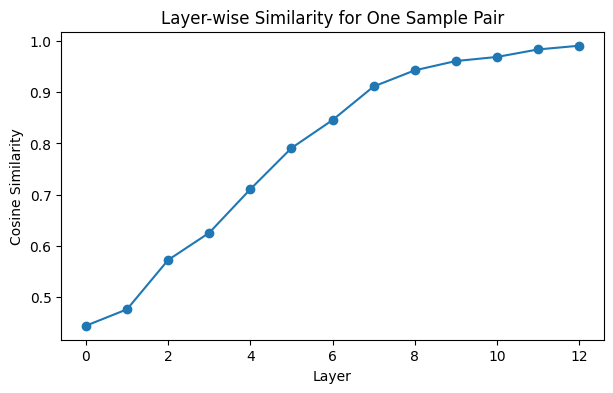

In [31]:
#plot the result of the test sample
import matplotlib.pyplot as plt
import numpy as np

layers = np.arange(len(sample_similarity))

plt.figure(figsize=(7, 4))
plt.plot(layers, sample_similarity, marker="o")
plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Layer-wise Similarity for One Sample Pair")
plt.show()

This single example suggests that Chinese and English representations may change their similarity across layers. However, this is only a sanity check, not enough evidence for a general conclusion. In the next section, I apply the same layer-wise similarity analysis to the full dataset to study whether this pattern holds more generally.

## 4. Research Question 1: General Cross-Lingual Alignment

The first research question asks whether semantically equivalent Chinese-English sentence pairs become more similar across the hidden layers of a multilingual model.

In this section, I do not separate the dataset into neutral and culturally loaded examples. Instead, I treat all sentence pairs as meaning-equivalent Chinese-English pairs. For each pair, I compute the cosine similarity between the English and Chinese sentence representations at every hidden layer.

If the model builds a shared multilingual semantic space, I expect the cosine similarity to be higher in deeper layers than in the initial embedding layer. However, this section does not claim that the model literally translates Chinese into English internally. It only studies whether the internal representations become more aligned across layers.

In [32]:
#compute layer-wise similarity for all sentence pairs
all_similarities = []

for i, row in df.iterrows():
    sims = compute_layerwise_similarity(
        english_text=row["english"],
        chinese_text=row["chinese"],
        tokenizer=tokenizer,
        model=model,
        device=device
    )
    all_similarities.append(sims)

similarity_matrix = np.array(all_similarities)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (100, 13)


In [33]:
#store layer-wise similarity results
num_layers = similarity_matrix.shape[1]
layer_cols = [f"layer_{i}" for i in range(num_layers)]

sim_df = pd.DataFrame(similarity_matrix, columns=layer_cols)

meta_cols = ["category", "english", "chinese"]

if "id" in df.columns:
    meta_cols = ["id"] + meta_cols

if "subcategory" in df.columns:
    meta_cols = meta_cols[:2] + ["subcategory"] + meta_cols[2:]

result_df = pd.concat(
    [df[meta_cols].reset_index(drop=True), sim_df],
    axis=1
)

result_df.head()

,id,category,subcategory,english,chinese,layer_0,layer_1,layer_2,layer_3,layer_4,layer_5,layer_6,layer_7,layer_8,layer_9,layer_10,layer_11,layer_12
0,1,neutral,everyday_action,I opened the window in the morning.,我早上打开了窗户。,0.444309,0.476355,0.572587,0.625609,0.710661,0.790937,0.845594,0.911106,0.942614,0.960781,0.968744,0.983375,0.990663
1,2,neutral,everyday_action,She washed her cup after breakfast.,她吃完早饭后洗了杯子。,0.381195,0.431978,0.513099,0.587413,0.688368,0.760890,0.821425,0.860445,0.902026,0.936213,0.952081,0.967008,0.963301
2,3,neutral,everyday_action,He put his keys on the table.,他把钥匙放在桌上。,0.357716,0.439831,0.523235,0.593277,0.678100,0.799424,0.866773,0.905789,0.930887,0.948848,0.958320,0.964611,0.964311
3,4,neutral,everyday_action,I walked to the store nearby.,我走路去了附近的商店。,0.433022,0.457392,0.540127,0.606495,0.677400,0.780220,0.848494,0.890616,0.918098,0.938481,0.946691,0.959858,0.968485
4,5,neutral,everyday_action,They cleaned the room together.,他们一起打扫了房间。,0.483948,0.486789,0.545676,0.597457,0.672142,0.778169,0.846662,0.905478,0.931153,0.949506,0.960613,0.977958,0.987484


In [34]:
#compute average similarity across all sentence pairs

layers = np.arange(num_layers)

mean_sim = similarity_matrix.mean(axis=0)
std_sim = similarity_matrix.std(axis=0)

rq1_summary = pd.DataFrame({
    "layer": layers,
    "mean_similarity": mean_sim,
    "std_similarity": std_sim
})

rq1_summary

,layer,mean_similarity,std_similarity
0,0,0.414078,0.062132
1,1,0.440851,0.055082
2,2,0.514261,0.053351
3,3,0.563337,0.058738
4,4,0.617625,0.077300
5,5,0.688803,0.093564
6,6,0.740051,0.105736
7,7,0.802126,0.102325
8,8,0.840081,0.094317
9,9,0.873546,0.082284


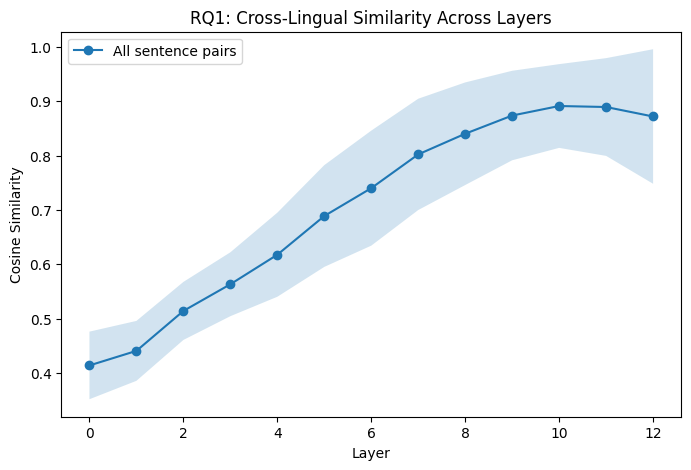

In [35]:
#plot average cross-lingual similarity across layers
plt.figure(figsize=(8, 5))

plt.plot(layers, mean_sim, marker="o", label="All sentence pairs")
plt.fill_between(
    layers,
    mean_sim - std_sim,
    mean_sim + std_sim,
    alpha=0.2
)

plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("RQ1: Cross-Lingual Similarity Across Layers")
plt.legend()
plt.show()

In [36]:
#compare initial-layer and final-layer similarity
initial_sim = similarity_matrix[:, 0]
final_sim = similarity_matrix[:, -1]

rq1_change = pd.DataFrame({
    "initial_layer_similarity": initial_sim,
    "final_layer_similarity": final_sim,
    "increase": final_sim - initial_sim
})

rq1_change.describe()

,initial_layer_similarity,final_layer_similarity,increase
count,100.000000,100.000000,100.000000
mean,0.414078,0.871770,0.457692
std,0.062445,0.124310,0.101343
min,0.247073,0.416633,0.095936
25%,0.374288,0.834167,0.408276
50%,0.414627,0.912785,0.483444
75%,0.443829,0.964637,0.523364
max,0.571772,0.990902,0.606595


In [37]:
#paired t-test
from scipy.stats import ttest_rel, wilcoxon

t_stat, p_value = ttest_rel(final_sim, initial_sim)
w_stat, w_p_value = wilcoxon(final_sim, initial_sim)

rq1_test = pd.DataFrame({
    "comparison": ["final_layer_vs_initial_layer"],
    "initial_mean": [initial_sim.mean()],
    "final_mean": [final_sim.mean()],
    "mean_increase": [(final_sim - initial_sim).mean()],
    "paired_t_test_p_value": [p_value],
    "wilcoxon_p_value": [w_p_value]
})

rq1_test

,comparison,initial_mean,final_mean,mean_increase,paired_t_test_p_value,wilcoxon_p_value
0,final_layer_vs_initial_layer,0.414078,0.87177,0.457692,7.163945e-68,3.896560e-18


### RQ1 Finding

The result shows a clear overall increase in cross-lingual similarity across layers. The average cosine similarity starts at about 0.414 in the initial embedding layer and increases to about 0.872 in the final layer. On average, the final-layer similarity is about 0.458 higher than the initial-layer similarity.

The layer-wise curve is not perfectly monotonic, since the similarity slightly drops in the last layer. However, the overall pattern is still clear: semantically equivalent Chinese-English sentence pairs become much more similar in deeper layers than in the initial layer.

The paired t-test and Wilcoxon test both give very small p-values, suggesting that the increase from the initial layer to the final layer is statistically strong in this dataset.

This supports RQ1: the multilingual model appears to gradually map semantically equivalent Chinese and English sentences into a more aligned representation space across its hidden layers. However, this result does not prove that the model literally translates Chinese into English internally. Instead, it suggests that the model develops more shared cross-lingual semantic representations in deeper layers.

## 5. Translation Baseline: Is Cross-Lingual Alignment the Same as Translation?

The result from RQ1 shows that semantically equivalent Chinese-English sentence pairs become more similar in deeper layers. This suggests that the multilingual model gradually builds cross-lingual alignment.

However, this result raises another question related to the original motivation of this project: is the model simply treating Chinese input as if it had already been translated into English?

To explore this question, I add a translation baseline. For each Chinese sentence, I use an English translation of that Chinese sentence. This gives three versions of the same meaning:

- the original English sentence,
- the original Chinese sentence,
- the translated English version of the Chinese sentence.

I compare two layer-wise similarity patterns:

1. original English vs original Chinese,
2. original English vs translated English.

If Chinese input were represented in the same way as its English translation from the beginning, then these two similarity patterns should be very similar even in early layers. However, if the translated-English pair has much higher similarity in early layers, while the Chinese-English pair only becomes close in deeper layers, this suggests that the model does not simply treat Chinese input as already-translated English at the shallow representation level.

In [39]:
#check does the model simply copy Chinese as Translated English
same_translation = (
    df["english"].str.strip().str.lower()
    == df["translated_english"].str.strip().str.lower()
)

same_translation.sum()

np.int64(0)

I first check the translated English column to make sure that each Chinese sentence has a corresponding English translation. I also check whether the translated English sentence is exactly the same as the original English sentence. Some overlap is acceptable for simple sentences, but too many identical sentences would make the translation baseline less informative. Luckily, we don't have any of them.

In [40]:
#compute layer-wise similarity for translation baseline
translation_similarities = []

for i, row in df.iterrows():
    sims = compute_layerwise_similarity(
        english_text=row["english"],
        chinese_text=row["translated_english"],
        tokenizer=tokenizer,
        model=model,
        device=device
    )
    translation_similarities.append(sims)

translation_matrix = np.array(translation_similarities)

print("Original English vs Chinese matrix:", similarity_matrix.shape)
print("Original English vs Translated English matrix:", translation_matrix.shape)

Original English vs Chinese matrix: (100, 13)
Original English vs Translated English matrix: (100, 13)


In [49]:
#compare average layer-wise similarity curves

english_chinese_mean = similarity_matrix.mean(axis=0)
english_chinese_std = similarity_matrix.std(axis=0)

english_translation_mean = translation_matrix.mean(axis=0)
english_translation_std = translation_matrix.std(axis=0)

translation_gap = english_translation_mean - english_chinese_mean

translation_summary = pd.DataFrame({
    "layer": layers,
    "english_chinese_mean": english_chinese_mean,
    "english_chinese_std": english_chinese_std,
    "english_translated_english_mean": english_translation_mean,
    "english_translated_english_std": english_translation_std,
    "translation_gap": translation_gap
})

translation_summary.head()

,layer,english_chinese_mean,english_chinese_std,english_translated_english_mean,english_translated_english_std,translation_gap
0,0,0.414078,0.062132,0.841774,0.075422,0.427696
1,1,0.440851,0.055082,0.855210,0.068215,0.414358
2,2,0.514261,0.053351,0.877600,0.058671,0.363339
3,3,0.563337,0.058738,0.886673,0.054986,0.323336
4,4,0.617625,0.077300,0.884494,0.059383,0.266869


$$
TG_l = \operatorname{sim}(E, T(C))_l - \operatorname{sim}(E, C)_l
$$

- \(TG_l): tranlsation gap of l
- \(E\): original English sentence
- \(C\): original Chinese sentence
- \(T(C)\): Chinese sentence translated into English


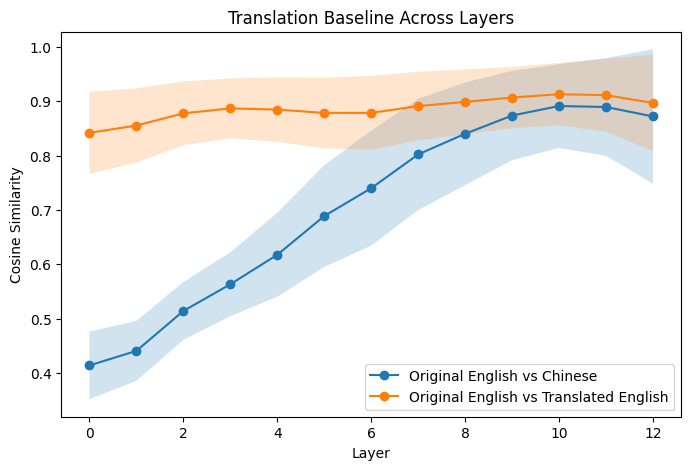

In [43]:
#plot translation baseline comparison
plt.figure(figsize=(8, 5))

plt.plot(
    layers,
    english_chinese_mean,
    marker="o",
    label="Original English vs Chinese"
)

plt.fill_between(
    layers,
    english_chinese_mean - english_chinese_std,
    english_chinese_mean + english_chinese_std,
    alpha=0.2
)

plt.plot(
    layers,
    english_translation_mean,
    marker="o",
    label="Original English vs Translated English"
)

plt.fill_between(
    layers,
    english_translation_mean - english_translation_std,
    english_translation_mean + english_translation_std,
    alpha=0.2
)

plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Translation Baseline Across Layers")
plt.legend()
plt.show()

In [46]:
#gap reduction from initial layer to final layer
initial_translation_gap = translation_gap[0]
final_translation_gap = translation_gap[-1]

translation_gap_df = pd.DataFrame({
    "initial_layer_gap": [initial_translation_gap],
    "final_layer_gap": [final_translation_gap],
    "gap_reduction": [initial_translation_gap - final_translation_gap]
})

translation_gap_df

,initial_layer_gap,final_layer_gap,gap_reduction
0,0.427696,0.024911,0.402786


In [48]:
#paired test for gap reduction
from scipy.stats import ttest_rel, wilcoxon

initial_pair_gap = translation_matrix[:, 0] - similarity_matrix[:, 0]
final_pair_gap = translation_matrix[:, -1] - similarity_matrix[:, -1]

t_stat, p_value = ttest_rel(initial_pair_gap, final_pair_gap)
w_stat, w_p_value = wilcoxon(initial_pair_gap, final_pair_gap)

translation_gap_test = pd.DataFrame({
    "comparison": ["initial_gap_vs_final_gap"],
    "initial_gap_mean": [initial_pair_gap.mean()],
    "final_gap_mean": [final_pair_gap.mean()],
    "gap_reduction_mean": [(initial_pair_gap - final_pair_gap).mean()],
    "paired_t_test_p_value": [p_value],
    "wilcoxon_p_value": [w_p_value]
})

translation_gap_test

,comparison,initial_gap_mean,final_gap_mean,gap_reduction_mean,paired_t_test_p_value,wilcoxon_p_value
0,initial_gap_vs_final_gap,0.427696,0.024911,0.402786,6.906816e-59,3.896560e-18


### Translation Baseline Finding

The translation baseline gives a clearer interpretation of the RQ1 result. In the early layers, the original English sentence and the translated English sentence have much higher similarity than the original English and Chinese sentence pair. The initial-layer gap between these two comparisons is about 0.428. This is expected because the original English sentence and the translated English sentence share the same language form.

However, this gap becomes much smaller in deeper layers. By the final layer, the gap is only about 0.025, with an average gap reduction of about 0.403. The paired t-test and Wilcoxon test both give very small p-values, suggesting that this reduction is statistically strong in this dataset.

This result suggests that the original Chinese input is not represented in the same way as its English translation in the shallow layers. Instead, the Chinese-English representation becomes closer to the English-English translation baseline as the input passes through deeper layers.

This does not directly prove whether the model internally translates Chinese into English. However, it provides evidence against a very simple translate-then-process explanation. The model appears to preserve language-specific differences in early layers and gradually build a more shared cross-lingual semantic representation in deeper layers.

## 6. Research Question 2: Neutral vs Culturally Loaded Alignment

The previous sections show that semantically equivalent Chinese-English sentence pairs become more aligned in deeper layers, and that this alignment is not simply the same as comparing an English sentence with its English translation.

The next question is whether this alignment behaves the same for different types of meaning. Neutral sentences usually describe simple daily meanings, such as actions, objects, weather, or school activities. These meanings often have direct equivalents across Chinese and English.

Culturally loaded sentences are different. They may contain cultural symbols, family values, social norms, traditions, colors, or idioms. Even when the literal translation is similar, the cultural associations may not be exactly the same across languages.

Therefore, this section compares neutral and culturally loaded sentence pairs. I focus on three aspects of alignment:

1. **Strength**: whether cultural pairs have lower cosine similarity.
2. **Speed**: whether cultural pairs reach high similarity later across layers.
3. **Stability**: whether cultural pairs show more fluctuation across layers.

The second research question is:

**RQ2: Is cross-lingual alignment weaker, slower, or less stable for culturally loaded sentence pairs compared with neutral sentence pairs?**

In [50]:
#check category labels
result_df["category"].value_counts()

,count
category,
neutral,50
cultural,50


In [51]:
#split into neutral and cultural groups
neutral_df = result_df[result_df["category"] == "neutral"]
cultural_df = result_df[result_df["category"] == "cultural"]

neutral_matrix = neutral_df[layer_cols].values
cultural_matrix = cultural_df[layer_cols].values

print("Neutral matrix shape:", neutral_matrix.shape)
print("Cultural matrix shape:", cultural_matrix.shape)

Neutral matrix shape: (50, 13)
Cultural matrix shape: (50, 13)


In [53]:
#compute group-level layer-wise similarity
neutral_mean = neutral_matrix.mean(axis=0)
neutral_std = neutral_matrix.std(axis=0)

cultural_mean = cultural_matrix.mean(axis=0)
cultural_std = cultural_matrix.std(axis=0)

neutral_cultural_gap = neutral_mean - cultural_mean

rq2_summary = pd.DataFrame({
    "layer": layers,
    "neutral_mean": neutral_mean,
    "neutral_std": neutral_std,
    "cultural_mean": cultural_mean,
    "cultural_std": cultural_std,
    "neutral_minus_cultural_gap": neutral_cultural_gap
})

rq2_summary.head()

,layer,neutral_mean,neutral_std,cultural_mean,cultural_std,neutral_minus_cultural_gap
0,0,0.442899,0.049242,0.385256,0.060288,0.057643
1,1,0.467333,0.038362,0.414370,0.056515,0.052964
2,2,0.539660,0.039194,0.488861,0.053537,0.050799
3,3,0.591886,0.040782,0.534788,0.060059,0.057098
4,4,0.663802,0.047325,0.571448,0.073800,0.092354


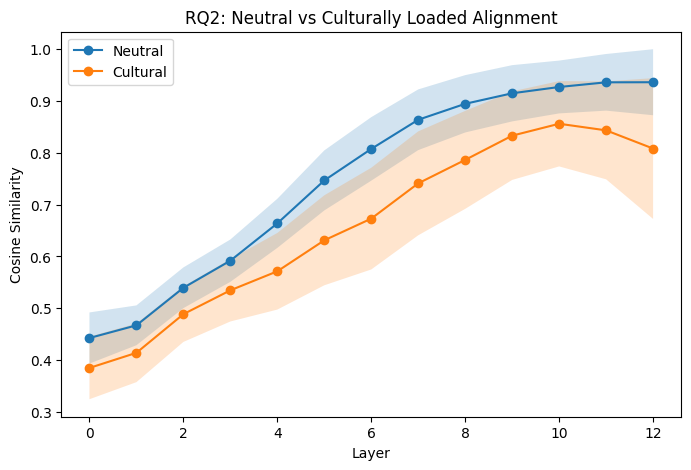

In [55]:
#plot neutral vs cultural layer-wise similarity
plt.figure(figsize=(8, 5))

plt.plot(
    layers,
    neutral_mean,
    marker="o",
    label="Neutral"
)

plt.fill_between(
    layers,
    neutral_mean - neutral_std,
    neutral_mean + neutral_std,
    alpha=0.2
)

plt.plot(
    layers,
    cultural_mean,
    marker="o",
    label="Cultural"
)

plt.fill_between(
    layers,
    cultural_mean - cultural_std,
    cultural_mean + cultural_std,
    alpha=0.2
)

plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("RQ2: Neutral vs Culturally Loaded Alignment")
plt.legend()
plt.show()

In [56]:
#define example-level alignment metrics
def first_alignment_layer(similarities, threshold=0.8):
    for i, sim in enumerate(similarities):
        if sim >= threshold:
            return i
    return np.nan

In [59]:
threshold = 0.8

result_df["avg_similarity"] = result_df[layer_cols].mean(axis=1)
result_df["initial_layer_similarity"] = result_df[layer_cols[0]]
result_df["final_layer_similarity"] = result_df[layer_cols[-1]]

result_df["alignment_gain"] = (
    result_df["final_layer_similarity"]
    - result_df["initial_layer_similarity"]
)

result_df["alignment_onset"] = result_df[layer_cols].apply(
    lambda row: first_alignment_layer(row.values, threshold=threshold),
    axis=1
)

result_df["layerwise_variation"] = result_df[layer_cols].std(axis=1)

result_df[
    [
        "category",
        "avg_similarity",
        "initial_layer_similarity",
        "final_layer_similarity",
        "alignment_gain",
        "alignment_onset",
        "layerwise_variation"
    ]
].head()

,category,avg_similarity,initial_layer_similarity,final_layer_similarity,alignment_gain,alignment_onset,layerwise_variation
0,neutral,0.786410,0.444309,0.990663,0.546354,6.0,0.199608
1,neutral,0.751188,0.381195,0.963301,0.582106,6.0,0.210579
2,neutral,0.763933,0.357716,0.964311,0.606595,6.0,0.219225
3,neutral,0.766568,0.433022,0.968485,0.535464,6.0,0.199389
4,neutral,0.778695,0.483948,0.987484,0.503536,6.0,0.195808


To compare the two groups more directly, I compute example-level metrics. Average similarity and final-layer similarity measure alignment strength. Alignment gain measures how much the Chinese-English similarity increases from the initial layer to the final layer. Alignment onset measures the first layer where the similarity reaches a selected threshold, here 0.8. A later onset means the pair needs more layers to become strongly aligned. I also compute layer-wise variation to measure how much the similarity changes across layers.

In [60]:
#compare example-level metrics by category
metric_cols = [
    "avg_similarity",
    "initial_layer_similarity",
    "final_layer_similarity",
    "alignment_gain",
    "alignment_onset",
    "layerwise_variation"
]

rq2_metric_summary = result_df.groupby("category")[metric_cols].mean()

rq2_metric_summary

,avg_similarity,initial_layer_similarity,final_layer_similarity,alignment_gain,alignment_onset,layerwise_variation
category,,,,,,
cultural,0.658839,0.385256,0.807888,0.422632,7.894737,0.169693
neutral,0.748360,0.442899,0.935651,0.492752,6.437500,0.187164


/tmp/ipykernel_5147/1610917172.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


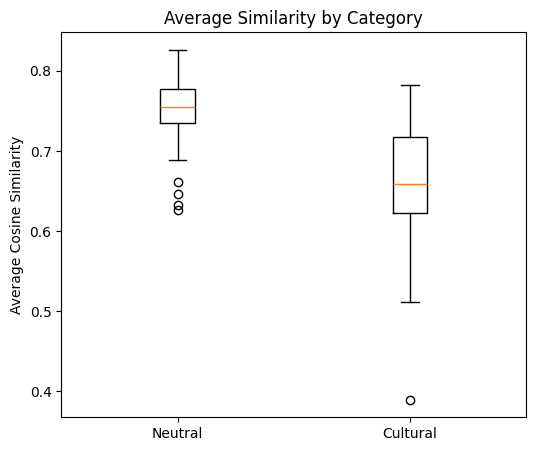

In [61]:
#average similarity by category
neutral_values = result_df[result_df["category"] == "neutral"]["avg_similarity"]
cultural_values = result_df[result_df["category"] == "cultural"]["avg_similarity"]

plt.figure(figsize=(6, 5))
plt.boxplot(
    [neutral_values, cultural_values],
    labels=["Neutral", "Cultural"]
)
plt.ylabel("Average Cosine Similarity")
plt.title("Average Similarity by Category")
plt.show()

/tmp/ipykernel_5147/2630696656.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


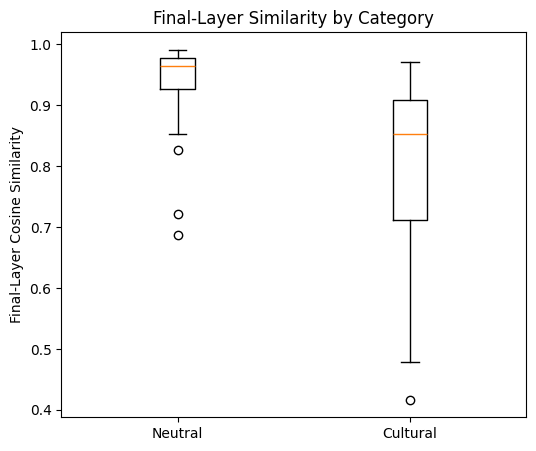

In [62]:
#final-layer similarity by category
neutral_values = result_df[result_df["category"] == "neutral"]["final_layer_similarity"]
cultural_values = result_df[result_df["category"] == "cultural"]["final_layer_similarity"]

plt.figure(figsize=(6, 5))
plt.boxplot(
    [neutral_values, cultural_values],
    labels=["Neutral", "Cultural"]
)
plt.ylabel("Final-Layer Cosine Similarity")
plt.title("Final-Layer Similarity by Category")
plt.show()

/tmp/ipykernel_5147/1673681845.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


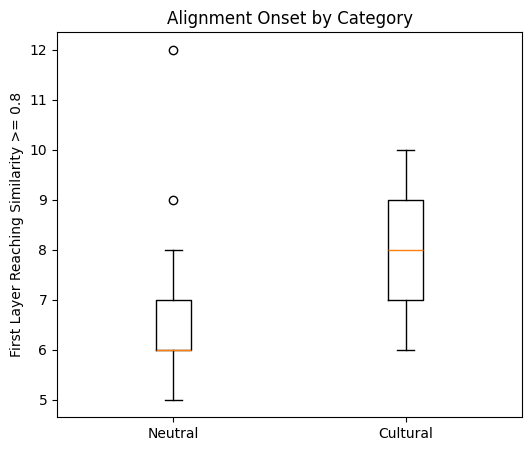

In [63]:
#alignment onset by category
neutral_values = result_df[result_df["category"] == "neutral"]["alignment_onset"].dropna()
cultural_values = result_df[result_df["category"] == "cultural"]["alignment_onset"].dropna()

plt.figure(figsize=(6, 5))
plt.boxplot(
    [neutral_values, cultural_values],
    labels=["Neutral", "Cultural"]
)
plt.ylabel("First Layer Reaching Similarity >= 0.8")
plt.title("Alignment Onset by Category")
plt.show()

In [64]:
#statistical tests for RQ2
from scipy.stats import ttest_ind, mannwhitneyu

neutral_examples = result_df[result_df["category"] == "neutral"]
cultural_examples = result_df[result_df["category"] == "cultural"]

stat_results = []

for metric in metric_cols:
    neutral_values = neutral_examples[metric].dropna()
    cultural_values = cultural_examples[metric].dropna()

    t_stat, p_value = ttest_ind(
        neutral_values,
        cultural_values,
        equal_var=False
    )

    u_stat, mw_p_value = mannwhitneyu(
        neutral_values,
        cultural_values,
        alternative="two-sided"
    )

    stat_results.append({
        "metric": metric,
        "neutral_mean": neutral_values.mean(),
        "cultural_mean": cultural_values.mean(),
        "difference_neutral_minus_cultural": neutral_values.mean() - cultural_values.mean(),
        "t_test_p_value": p_value,
        "mann_whitney_p_value": mw_p_value
    })

rq2_stat_df = pd.DataFrame(stat_results)
rq2_stat_df

,metric,neutral_mean,cultural_mean,difference_neutral_minus_cultural,t_test_p_value,mann_whitney_p_value
0,avg_similarity,0.748360,0.658839,0.089521,5.571587e-10,5.610873e-10
1,initial_layer_similarity,0.442899,0.385256,0.057643,1.237580e-06,1.745433e-06
2,final_layer_similarity,0.935651,0.807888,0.127763,8.978741e-08,3.251985e-09
3,alignment_gain,0.492752,0.422632,0.070120,4.105033e-04,9.021942e-04
4,alignment_onset,6.437500,7.894737,-1.457237,1.184356e-07,3.130773e-08
5,layerwise_variation,0.187164,0.169693,0.017471,7.931502e-04,2.053665e-04


In [65]:
#effect size
def cohens_d(x, y):
    x = np.array(x)
    y = np.array(y)

    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1))
        / (nx + ny - 2)
    )

    return (np.mean(x) - np.mean(y)) / pooled_std

In [66]:
effect_results = []

for metric in metric_cols:
    neutral_values = neutral_examples[metric].dropna().values
    cultural_values = cultural_examples[metric].dropna().values

    effect_results.append({
        "metric": metric,
        "cohens_d_neutral_minus_cultural": cohens_d(neutral_values, cultural_values)
    })

rq2_effect_df = pd.DataFrame(effect_results)

rq2_stat_df = rq2_stat_df.merge(rq2_effect_df, on="metric")
rq2_stat_df

,metric,neutral_mean,cultural_mean,difference_neutral_minus_cultural,t_test_p_value,mann_whitney_p_value,cohens_d_neutral_minus_cultural
0,avg_similarity,0.748360,0.658839,0.089521,5.571587e-10,5.610873e-10,1.422370
1,initial_layer_similarity,0.442899,0.385256,0.057643,1.237580e-06,1.745433e-06,1.036719
2,final_layer_similarity,0.935651,0.807888,0.127763,8.978741e-08,3.251985e-09,1.194175
3,alignment_gain,0.492752,0.422632,0.070120,4.105033e-04,9.021942e-04,0.734204
4,alignment_onset,6.437500,7.894737,-1.457237,1.184356e-07,3.130773e-08,-1.276962
5,layerwise_variation,0.187164,0.169693,0.017471,7.931502e-04,2.053665e-04,0.692736


### RQ2 Finding

The results support the second research question. Both neutral and culturally loaded sentence pairs become more aligned in deeper layers, but the neutral pairs show stronger and earlier alignment.

The average similarity is higher for neutral examples than for culturally loaded examples. The neutral group has an average similarity of about 0.748, while the cultural group has an average similarity of about 0.659. The difference is statistically significant, and the effect size is large.

The final-layer similarity also shows a clear difference. Neutral examples reach an average final-layer similarity of about 0.936, while cultural examples reach about 0.808. This suggests that culturally loaded sentence pairs do not fully catch up with neutral sentence pairs even in the deepest layer.

The alignment onset result also supports this pattern. Using a threshold of 0.8, neutral examples reach high similarity around layer 6.44 on average, while cultural examples reach it around layer 7.89. Since a larger onset value means later alignment, this suggests that culturally loaded examples need more layers to become strongly aligned.

Overall, these results suggest that culturally loaded meanings are harder for the model to align across Chinese and English. The cultural examples are not unaligned, but their alignment is weaker and slower compared with neutral examples. This supports the idea that literal semantic equivalence does not always mean identical internal representation, especially when cultural associations are involved.

## 7. Shuffled Baseline: Correct Pairs vs Mismatched Pairs

The previous sections show that semantically equivalent Chinese-English sentence pairs become more aligned in deeper layers. However, I also want to make sure that this high similarity is not simply caused by the multilingual model mapping all English and Chinese inputs into a generally similar representation space.

To check this, I use a shuffled baseline. In this baseline, each original English sentence is paired with an incorrect Chinese sentence from another row. This breaks the semantic match while keeping the same English sentence set, the same Chinese sentence set, and the same model.

If the cosine similarity mainly reflects semantic equivalence, then the correct Chinese-English pairs should have higher similarity than the shuffled mismatched pairs.

In [67]:
#create shuffled Chinese-English pairs
shuffled_df = df.copy()

shuffled_df["shuffled_chinese"] = shuffled_df["chinese"].sample(

    frac=1,

    random_state=42

).reset_index(drop=True)

same_match = shuffled_df["chinese"] == shuffled_df["shuffled_chinese"]

if same_match.any():

    shuffled_df.loc[same_match, "shuffled_chinese"] = shuffled_df["shuffled_chinese"].shift(1)

shuffled_df[["english", "chinese", "shuffled_chinese"]].head(10)

,english,chinese,shuffled_chinese
0,I opened the window in the morning.,我早上打开了窗户。,遇到困难也不要轻易放弃。
1,She washed her cup after breakfast.,她吃完早饭后洗了杯子。,端午节时人们会吃粽子。
2,He put his keys on the table.,他把钥匙放在桌上。,春节时人们会发红包。
3,I walked to the store nearby.,我走路去了附近的商店。,我晚饭后给朋友打了电话。
4,They cleaned the room together.,他们一起打扫了房间。,我们在日落前完成了。
5,The bag is under the chair.,包在椅子下面。,面条太烫了没法马上吃。
6,This notebook has a blue cover.,这个笔记本是蓝色封面的。,他午饭时看了邮件。
7,The phone battery is low.,手机快没电了。,他终于恍然大悟了。
8,There is a bottle on the desk.,桌上有一个瓶子。,下课后我觉得很累。
9,My jacket is in the closet.,我的外套在衣柜里。,我早上打开了窗户。


In [68]:
#compute layer-wise similarity for shuffled baseline
shuffled_similarities = []

for i, row in shuffled_df.iterrows():
    sims = compute_layerwise_similarity(
        english_text=row["english"],
        chinese_text=row["shuffled_chinese"],
        tokenizer=tokenizer,
        model=model,
        device=device
    )
    shuffled_similarities.append(sims)

shuffled_matrix = np.array(shuffled_similarities)

print("Correct pair matrix:", similarity_matrix.shape)
print("Shuffled pair matrix:", shuffled_matrix.shape)

Correct pair matrix: (100, 13)
Shuffled pair matrix: (100, 13)


In [69]:
#compare correct and shuffled layer-wise similarity
correct_mean = similarity_matrix.mean(axis=0)
correct_std = similarity_matrix.std(axis=0)

shuffled_mean = shuffled_matrix.mean(axis=0)
shuffled_std = shuffled_matrix.std(axis=0)

shuffled_gap = correct_mean - shuffled_mean

shuffled_summary = pd.DataFrame({
    "layer": layers,
    "correct_pair_mean": correct_mean,
    "correct_pair_std": correct_std,
    "shuffled_pair_mean": shuffled_mean,
    "shuffled_pair_std": shuffled_std,
    "correct_minus_shuffled_gap": shuffled_gap
})

shuffled_summary

,layer,correct_pair_mean,correct_pair_std,shuffled_pair_mean,shuffled_pair_std,correct_minus_shuffled_gap
0,0,0.414078,0.062132,0.295969,0.058202,0.118109
1,1,0.440851,0.055082,0.311530,0.046660,0.129321
2,2,0.514261,0.053351,0.382575,0.047369,0.131686
3,3,0.563337,0.058738,0.403365,0.053352,0.159972
4,4,0.617625,0.077300,0.388541,0.067756,0.229084
5,5,0.688803,0.093564,0.383953,0.080617,0.304850
6,6,0.740051,0.105736,0.381497,0.092281,0.358555
7,7,0.802126,0.102325,0.407041,0.107094,0.395085
8,8,0.840081,0.094317,0.414439,0.117818,0.425643
9,9,0.873546,0.082284,0.425606,0.134310,0.447940


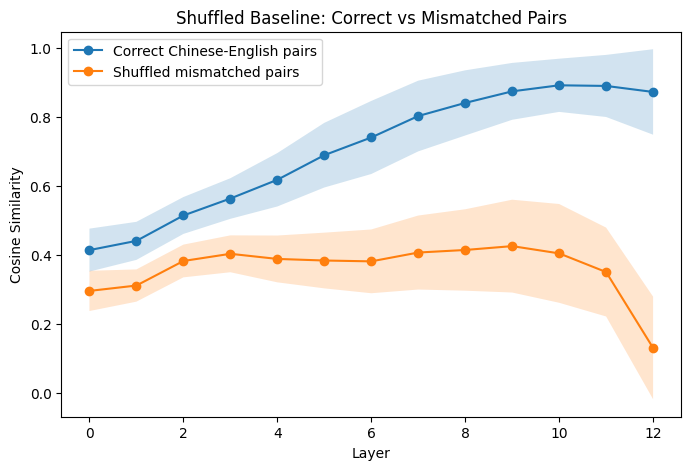

In [70]:
#plot correct vs shuffled baseline
plt.figure(figsize=(8, 5))

plt.plot(
    layers,
    correct_mean,
    marker="o",
    label="Correct Chinese-English pairs"
)

plt.fill_between(
    layers,
    correct_mean - correct_std,
    correct_mean + correct_std,
    alpha=0.2
)

plt.plot(
    layers,
    shuffled_mean,
    marker="o",
    label="Shuffled mismatched pairs"
)

plt.fill_between(
    layers,
    shuffled_mean - shuffled_std,
    shuffled_mean + shuffled_std,
    alpha=0.2
)

plt.xlabel("Layer")
plt.ylabel("Cosine Similarity")
plt.title("Shuffled Baseline: Correct vs Mismatched Pairs")
plt.legend()
plt.show()

In [71]:
#final-layer comparison

correct_final = similarity_matrix[:, -1]
shuffled_final = shuffled_matrix[:, -1]

shuffled_final_df = pd.DataFrame({
    "correct_final_similarity": correct_final,
    "shuffled_final_similarity": shuffled_final,
    "difference": correct_final - shuffled_final
})

shuffled_final_df.describe()

,correct_final_similarity,shuffled_final_similarity,difference
count,100.000000,100.000000,100.000000
mean,0.871770,0.130936,0.740834
std,0.124310,0.149180,0.193090
min,0.416633,-0.101339,0.247781
25%,0.834167,0.021197,0.633157
50%,0.912785,0.115549,0.767480
75%,0.964637,0.225465,0.890759
max,0.990902,0.603757,1.080372


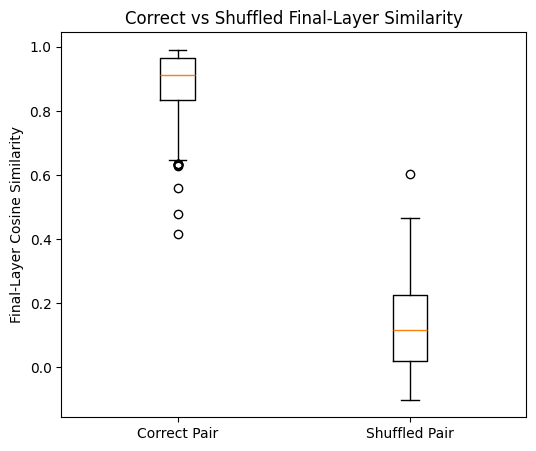

In [72]:
#boxplot of final-layer similarity

plt.figure(figsize=(6, 5))

plt.boxplot(
    [correct_final, shuffled_final],
    tick_labels=["Correct Pair", "Shuffled Pair"]
)

plt.ylabel("Final-Layer Cosine Similarity")
plt.title("Correct vs Shuffled Final-Layer Similarity")
plt.show()

In [73]:
#paired statistical test
from scipy.stats import ttest_rel, wilcoxon

t_stat, p_value = ttest_rel(correct_final, shuffled_final)
w_stat, w_p_value = wilcoxon(correct_final, shuffled_final)

shuffled_baseline_test = pd.DataFrame({
    "comparison": ["correct_vs_shuffled_final_layer"],
    "correct_mean": [correct_final.mean()],
    "shuffled_mean": [shuffled_final.mean()],
    "mean_difference": [(correct_final - shuffled_final).mean()],
    "paired_t_test_p_value": [p_value],
    "wilcoxon_p_value": [w_p_value]
})

shuffled_baseline_test

,comparison,correct_mean,shuffled_mean,mean_difference,paired_t_test_p_value,wilcoxon_p_value
0,correct_vs_shuffled_final_layer,0.87177,0.130936,0.740834,3.086966e-61,3.896560e-18


### Shuffled Baseline Finding

The shuffled baseline shows a clear difference between correct Chinese-English pairs and mismatched Chinese-English pairs. The correct pairs have an average final-layer similarity of about 0.872, while the shuffled pairs have an average final-layer similarity of only about 0.131. The mean difference is about 0.741, and both the paired t-test and Wilcoxon test show a very small p-value.

This result suggests that the high similarity observed in the main experiment is not simply caused by the multilingual model mapping all English and Chinese inputs into a generally similar space. If that were the case, the shuffled mismatched pairs would also have high similarity. Instead, the shuffled pairs remain much lower, which means the similarity is strongly related to semantic matching between the English and Chinese sentences.

This baseline supports the interpretation of the earlier results. The increasing similarity across layers is not just a general multilingual effect. It reflects the model's ability to bring semantically equivalent Chinese-English pairs closer together in its representation space.

## 8. Confound and Robustness Checks

The previous sections suggest that culturally loaded sentence pairs show weaker and later cross-lingual alignment than neutral sentence pairs. However, this difference may be affected by other factors.

In this section, I run two additional checks. First, I examine sentence length as a possible confounding factor, because cultural examples may be longer or more abstract than neutral examples. Second, I test whether the alignment-onset result depends too much on the selected threshold of 0.8.

In [74]:
#sentence length confound check
result_df["english_word_count"] = result_df["english"].apply(
    lambda x: len(str(x).split())
)

result_df["chinese_char_count"] = result_df["chinese"].apply(
    lambda x: len(str(x))
)

result_df[
    ["category", "english", "chinese", "english_word_count", "chinese_char_count"]
].head()

,category,english,chinese,english_word_count,chinese_char_count
0,neutral,I opened the window in the morning.,我早上打开了窗户。,7,9
1,neutral,She washed her cup after breakfast.,她吃完早饭后洗了杯子。,6,11
2,neutral,He put his keys on the table.,他把钥匙放在桌上。,7,9
3,neutral,I walked to the store nearby.,我走路去了附近的商店。,6,11
4,neutral,They cleaned the room together.,他们一起打扫了房间。,5,10


In [75]:
length_summary = result_df.groupby("category")[
    ["english_word_count", "chinese_char_count"]
].agg(["mean", "std"])

length_summary

english_word_count           chinese_char_count          
                       mean       std               mean       std
category                                                          
cultural               7.82  1.100835              12.90  2.270036
neutral                6.08  0.778276               9.66  1.673442

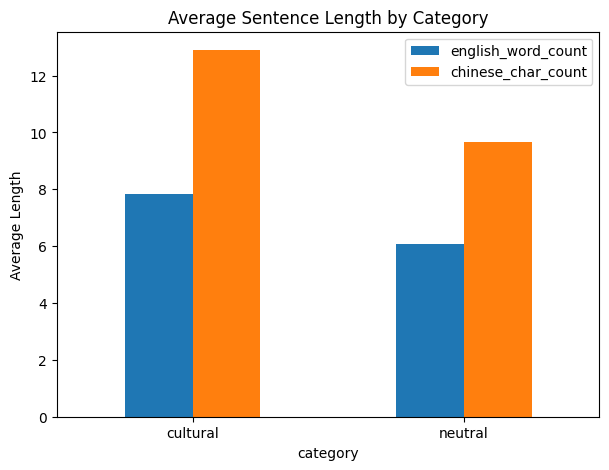

In [76]:
length_summary_simple = result_df.groupby("category")[
    ["english_word_count", "chinese_char_count"]
].mean()

length_summary_simple.plot(kind="bar", figsize=(7, 5))

plt.ylabel("Average Length")
plt.title("Average Sentence Length by Category")
plt.xticks(rotation=0)
plt.show()

In [77]:
length_corr = pd.DataFrame({
    "length_feature": ["english_word_count", "chinese_char_count"],
    "corr_with_avg_similarity": [
        result_df["english_word_count"].corr(result_df["avg_similarity"]),
        result_df["chinese_char_count"].corr(result_df["avg_similarity"])
    ],
    "corr_with_final_similarity": [
        result_df["english_word_count"].corr(result_df["final_layer_similarity"]),
        result_df["chinese_char_count"].corr(result_df["final_layer_similarity"])
    ],
    "corr_with_alignment_onset": [
        result_df["english_word_count"].corr(result_df["alignment_onset"]),
        result_df["chinese_char_count"].corr(result_df["alignment_onset"])
    ]
})

length_corr

,length_feature,corr_with_avg_similarity,corr_with_final_similarity,corr_with_alignment_onset
0,english_word_count,-0.376111,-0.30581,0.294047
1,chinese_char_count,-0.334683,-0.28801,0.342875


I include this check because sentence length may affect representation similarity. If cultural examples are longer on average, then part of the neutral-cultural difference may be related to length instead of cultural meaning alone.

This check does not fully remove the confound, but it helps interpret the result more carefully.

In [78]:
import statsmodels.formula.api as smf

reg_df = result_df.copy()
reg_df["is_cultural"] = (reg_df["category"] == "cultural").astype(int)

length_control_model = smf.ols(
    "avg_similarity ~ is_cultural + english_word_count + chinese_char_count",
    data=reg_df
).fit()

print(length_control_model.summary())

                            OLS Regression Results                            
Dep. Variable:         avg_similarity   R-squared:                       0.343
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     16.68
Date:                Tue, 12 May 2026   Prob (F-statistic):           8.41e-09
Time:                        20:17:41   Log-Likelihood:                 135.85
No. Observations:                 100   AIC:                            -263.7
Df Residuals:                      96   BIC:                            -253.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.7258      0

In [79]:
final_length_control_model = smf.ols(
    "final_layer_similarity ~ is_cultural + english_word_count + chinese_char_count",
    data=reg_df
).fit()

print(final_length_control_model.summary())

                              OLS Regression Results                              
Dep. Variable:     final_layer_similarity   R-squared:                       0.272
Model:                                OLS   Adj. R-squared:                  0.249
Method:                     Least Squares   F-statistic:                     11.93
Date:                    Tue, 12 May 2026   Prob (F-statistic):           1.04e-06
Time:                            20:17:50   Log-Likelihood:                 82.951
No. Observations:                     100   AIC:                            -157.9
Df Residuals:                          96   BIC:                            -147.5
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

I also fit a simple linear regression to check whether the category effect remains after controlling for English and Chinese sentence length. This is not meant to prove causality, but it provides a basic robustness check for the neutral-cultural comparison.

### Sentence Length Confound Check Finding

The correlation results show that sentence length has some relationship with the alignment metrics. Longer English and Chinese sentences tend to have lower average similarity and lower final-layer similarity. They also tend to reach the alignment threshold later. This suggests that sentence length is a possible confounding factor and should not be ignored.

However, the regression results show that sentence length does not fully explain the neutral-cultural difference. After controlling for English word count and Chinese character count, the cultural category coefficient remains negative and statistically significant for both average similarity and final-layer similarity. In contrast, the English and Chinese length variables are not statistically significant in these regression models.

For average similarity, the cultural coefficient is about -0.097. For final-layer similarity, the cultural coefficient is about -0.146. This means that culturally loaded examples still show weaker alignment even after accounting for sentence length.

Therefore, sentence length may be related to alignment, but it does not appear to be the main explanation for the cultural alignment gap in this dataset.

In [80]:
# threshold sensitivity for alignment onset
thresholds = [0.70, 0.75, 0.80, 0.85]

threshold_results = []

for threshold in thresholds:
    onset_col = f"alignment_onset_{threshold}"

    result_df[onset_col] = result_df[layer_cols].apply(
        lambda row: first_alignment_layer(row.values, threshold=threshold),
        axis=1
    )

    neutral_onset = result_df[result_df["category"] == "neutral"][onset_col].dropna()
    cultural_onset = result_df[result_df["category"] == "cultural"][onset_col].dropna()

    threshold_results.append({
        "threshold": threshold,
        "neutral_mean_onset": neutral_onset.mean(),
        "cultural_mean_onset": cultural_onset.mean(),
        "neutral_minus_cultural": neutral_onset.mean() - cultural_onset.mean(),
        "neutral_count_reached": len(neutral_onset),
        "cultural_count_reached": len(cultural_onset)
    })

threshold_sensitivity_df = pd.DataFrame(threshold_results)
threshold_sensitivity_df

,threshold,neutral_mean_onset,cultural_mean_onset,neutral_minus_cultural,neutral_count_reached,cultural_count_reached
0,0.70,5.120000,6.673913,-1.553913,50,46
1,0.75,5.740000,7.400000,-1.660000,50,45
2,0.80,6.437500,7.894737,-1.457237,48,38
3,0.85,7.191489,8.757576,-1.566086,47,33


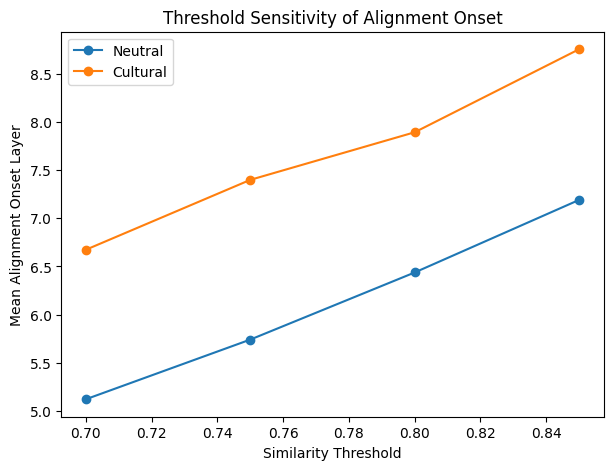

In [81]:
plt.figure(figsize=(7, 5))

plt.plot(
    threshold_sensitivity_df["threshold"],
    threshold_sensitivity_df["neutral_mean_onset"],
    marker="o",
    label="Neutral"
)

plt.plot(
    threshold_sensitivity_df["threshold"],
    threshold_sensitivity_df["cultural_mean_onset"],
    marker="o",
    label="Cultural"
)

plt.xlabel("Similarity Threshold")
plt.ylabel("Mean Alignment Onset Layer")
plt.title("Threshold Sensitivity of Alignment Onset")
plt.legend()
plt.show()

### Threshold Sensitivity Finding

The threshold sensitivity check shows that the delayed alignment pattern is consistent across different similarity thresholds. I test thresholds from 0.70 to 0.85, and cultural examples always reach the selected threshold later than neutral examples.

As the threshold becomes higher, both groups need deeper layers to reach the threshold. This is expected because a higher similarity requirement is harder to satisfy. However, the gap between neutral and cultural examples remains consistent: culturally loaded sentence pairs always have a later mean alignment onset.

This suggests that the RQ2 finding is not only caused by choosing 0.8 as the threshold. The result is robust across several reasonable threshold choices.

## 9. Discussion and Conclusion

### 9.1 Summary of Main Findings

This project studies how a multilingual model represents semantically equivalent Chinese and English sentences across its hidden layers. The motivation comes from the observation that asking the same question in Chinese and English can sometimes lead to different responses from large language models. Instead of directly comparing final generated answers, this project focuses on internal sentence representations.

The first research question asks whether Chinese-English sentence pairs with the same meaning become more aligned across model layers. The result supports this idea. Across all sentence pairs, the average cosine similarity increases from about 0.414 in the initial embedding layer to about 0.872 in the final layer. The average increase is about 0.458, and both the paired t-test and Wilcoxon test show a very small p-value. This suggests that the model gradually maps semantically equivalent Chinese and English sentences into a more shared representation space in deeper layers.

The translation baseline gives a more careful interpretation of this result. At the initial layer, the original English sentence is much closer to the translated English sentence than to the original Chinese sentence. The initial gap between the English-translation similarity and the English-Chinese similarity is about 0.428. However, this gap drops to about 0.025 in the final layer. This suggests that Chinese input is not represented like an English translation from the beginning. Instead, the model keeps language-specific differences in shallow layers and gradually builds more shared cross-lingual semantic representations in deeper layers.

The second research question asks whether culturally loaded meanings are harder to align than neutral meanings. The result supports this question. Neutral examples have higher average similarity than culturally loaded examples, with means of about 0.748 and 0.659. Neutral examples also have higher final-layer similarity, with means of about 0.936 and 0.808. In addition, neutral examples reach the 0.8 alignment threshold earlier than cultural examples, around layer 6.44 compared with layer 7.89. This suggests that culturally loaded sentence pairs are not unaligned, but their alignment is weaker and slower than neutral sentence pairs.

The shuffled baseline also supports the interpretation that the measured similarity is related to semantic matching. Correct Chinese-English pairs have an average final-layer similarity of about 0.872, while shuffled mismatched pairs have an average final-layer similarity of only about 0.131. This shows that the model is not simply mapping all English and Chinese inputs into the same space. Correct semantic pairing matters.

Finally, the confound and robustness checks make the result more careful. Sentence length is related to some alignment metrics: longer sentences tend to have lower similarity and later alignment onset. However, after controlling for English word count and Chinese character count, the cultural category still remains negatively associated with both average similarity and final-layer similarity. This suggests that sentence length does not fully explain the cultural alignment gap. The threshold sensitivity check also shows that cultural examples reach alignment later than neutral examples across several thresholds, not only at the selected threshold of 0.8.

### 9.2 Interpretation

Overall, the results suggest a layered view of cross-lingual representation. In shallow layers, Chinese and English inputs still preserve more language-specific information, such as tokenization, wording, and surface form. In deeper layers, semantically equivalent Chinese and English sentences become much more aligned.

This does not prove that the model internally translates Chinese into English. The experiment does not directly observe a translation step inside the model. Instead, the results suggest a more nuanced process. Chinese and English inputs start with different representations, but the model gradually maps them into a more shared multilingual semantic space.

The translation baseline is important for this interpretation. If Chinese input were represented like an English translation from the beginning, then the original English vs Chinese curve would be close to the original English vs translated English curve even in early layers. However, the early-layer gap is large, and the gap only becomes small in deeper layers. This provides evidence against a simple translate-then-process explanation.

The cultural analysis suggests that this shared semantic space is not perfect. Neutral meanings are easier to align because they often have direct equivalents across languages. Culturally loaded meanings may have similar literal translations, but they can carry different associations, background knowledge, or usage patterns in Chinese and English. This may explain why cultural examples show lower similarity and later alignment onset.

Therefore, the main finding is that multilingual alignment exists, but it is gradual and uneven. The model can align Chinese and English meanings, but cultural content appears to make this alignment more difficult.

### 9.3 Limitations

There are several limitations in this project.

First, the dataset is synthetic. This makes the experiment more controlled, but it may not fully represent real user prompts or natural multilingual communication. The results should therefore be interpreted as an exploratory analysis rather than a general benchmark.

Second, the cultural labels are manually defined. Cultural meaning is complex and not always binary. Some examples may be more culturally loaded than others. Future work could use more fine-grained categories, such as cultural symbols, family values, social norms, idioms, traditions, and color associations.

Third, this project uses one pretrained multilingual sentence-transformer model. The results may not generalize to all multilingual models or large generative LLMs. A stronger follow-up study could compare multiple models, such as multilingual BERT, XLM-R, and larger instruction-tuned models.

Fourth, cosine similarity is only one measure of representation alignment. It captures geometric closeness in the embedding space, but it may not fully capture pragmatic meaning, cultural associations, or differences in generated responses.

Fifth, this project studies internal representations rather than final model outputs. This makes the experiment more controlled, but it does not directly explain all cases where Chinese and English prompts produce different generated answers. Final responses can also be affected by decoding, instruction tuning, prompt wording, safety behavior, and training data distribution.

Finally, the regression check controls for sentence length, but it does not prove causality. Cultural category remains associated with lower alignment after controlling for length, but other factors such as abstractness, topic, or translation quality may also affect the results.

### 9.4 Conclusion

This project starts from a practical observation: asking the same question in Chinese and English can sometimes lead to different LLM responses. To study this more carefully, I analyze internal representations instead of final generated answers.

The results show that semantically equivalent Chinese-English sentence pairs become more aligned across the hidden layers of a multilingual model. This supports the idea that the model gradually builds a shared cross-lingual semantic representation.

However, this alignment is not the same as simply treating Chinese input as an English translation from the beginning. The translation baseline shows that Chinese and English inputs are quite different in shallow layers, but become much closer in deeper layers.

The results also show that culturally loaded examples are harder to align than neutral examples. Cultural examples have lower average similarity, lower final-layer similarity, and later alignment onset. This suggests that literal translation equivalence does not always mean identical internal representation, especially when cultural associations are involved.

Overall, the project suggests that multilingual models do build shared semantic representations across languages, but this alignment is gradual, imperfect, and sensitive to cultural content.